# TPI 1: Adquisición y Análisis Lingüístico de Medios

**Modalidad:** Trabajo Práctico Individual (calificación numérica de 0 a 10).

**Fecha de entrega y exposición:** Jueves 16 de abril. Se realizará de manera expositiva en remoto frente a todo el grupo de estudiantes (aproximadamente 10 minutos por presentación) para que entre quienes participan veamos posibles soluciones.

**Duración estimada de codificación:** 2 horas

**Desafío general:**
Vas a construir un sistema en Python que adquiera textos de la web y transcriba audio, los analice lingüísticamente con spaCy, genere visualizaciones profesionales y exponga los resultados en un dashboard interactivo con Gradio. Este Trabajo Práctico Integrador fusiona las competencias de adquisición de datos y procesamiento de lenguaje natural.

**Dinámica de resolución: pair programming con IA**
La unidad de trabajo está formada por vos y un asistente de IA. La IA puede proponer estrategias, explicar errores, sugerir variantes y auditar código. No reemplaza tu pensamiento ni tu criterio. Toda decisión final, toda justificación y toda versión entregada tienen que estar bajo tu responsabilidad.

---

### AI Reflection Log — Plantilla obligatoria
Completá al menos una entrada en este registro por cada parte del laboratorio.

| Parte | Objetivo de la consulta | Prompt o pedido a la IA | Qué responidó (resumen) | Qué conservaste y por qué | Qué descartaste y por qué | Qué aprendiste |
|---|---|---|---|---|---|---|
| **Parte 1** | Definir estrategia para unificar fuentes de datos heterogéneas (web, audio, JSON)| ¿Cómo debería estructurar las funciones de adquisición para manejar las diferencias de formato al unificar los datos en un único DataFrame? Necesito que cada fuente (web, audio, JSON) devuelva datos compatibles para la función unificar_corpus." | Recomendó aplicar normalización previa en cada función de adquisición, donde cada una devuelve una lista de diccionarios con claves estandarizadas: 'texto', 'titulo_o_fuente', 'origen'. | Conservé la approche de normalización previa porque aísla la complejidad de cada fuente, hace el código más mantenible y simplifica la función de unificación. | Descarté la normalización en la función de unificación porque habría centralizado demasiada lógica y hecho esa función más compleja y difícil de probar. | Aprendí que estandarizar la salida temprano en el pipeline reduce la carga cognitiva en etapas posteriores y facilita el debugging al poder validar cada fuente|
| **Parte 2** | Definir criterios para distinguir entre entidades PER, ORG, LOC usando spaCy ent.label_ e implementar el método extraer_entidades en la clase AnalizadorCorpus | Debo generar la clase AnalizadorCorpus con método llamado extraer entidades. Qué criterios debería tomar para poder distinguir entre las distintas entidades | La IA explicó que PER incluye nombres de individuos, ORG incluye empresas e instituciones, y LOC incluye lugares geográficos. Optimizó la clase AnalizadorCorpus, que procesa los documentos con nlp.pipe, recorre las entidades usando ent.label_, las agrupa por tipo con Counter, y devuelve un diccionario ordenado por frecuencia. | Conservé el enfoque de agrupar entidades por tipo usando Counter y devolver un diccionario ordenado por frecuencia, ya que permite análisis cuantitativo claro de las entidades más relevantes por categoría (PER, ORG, LOC) y facilita la visualización e interpretación de resultados. | Descarté simplemente listar entidades sin agregación por tipo. | Aprendí que validar las clasificaciones del modelo spaCy con ejemplos concretos del corpus es esencial para ajustar los criterios de interpretación, y que un enfoque sistemático para cada tipo de entidad (usando ent.label_ como base pero verificando con ejemplos reales) mejora significativamente la confiabilidad del análisis lingüístico en proyectos de NLP |
| **Parte 3**|Determinar la mejor visualización para frecuencias de palabras clave en informe de toma de decisiones | ¿Cuál sería la manera mas conveniente de visualizar los datos, un wordcloud o un barplot? Necesito mostrar las frecuencias de palabras claves en un informe dirigido a la toma de decisiones | El barplot permite comparar frecuencias con exactitud y es fácil de interpretar por stakeholders, mientras que el wordcloud brinda un impacto visual atractivo pero menos preciso y puede sesgar la percepción por el tamaño de fuente; recomendó usar el barplot como base para decisiones basadas en datos, reservando el wordcloud solo como complemento ilustrativo en resúmenes ejecutivos. | Conservé el barplot como visualización principal porque brinda comparaciones cuantitativas exactas, esencial para fundamentar decisiones.| Descarté depender exclusivamente del wordcloud debido a su falta de escala precisa y dificultad para ordenar por frecuencia, lo que podría llevar a conclusiones erróneas en un contexto donde la exactitud numérica es crítica para la toma de decisiones. | Aprendí que la elección de la visualización debe alinearse con el objetivo comunicacional: para apoyar decisiones se prioriza la precisión y facilidad de comparación (barplot), mientras que el wordcloud resulta útil en contextos exploratorios o de presentación informal |
| **Parte 4** | Optimizar la clase PipelineMediatico para orquestar los componentes del pipeline | ¿Cómo debería estructurar la clase PipelineMediatico para orquestar de manera eficiente las etapas de adquisición (web, audio, JSON), unificación y análisis lingüístico? | La IA explicó que debía aplicar el principio de responsabilidad única, separando claramente cada etapa en métodos independientes con manejo de errores específico, logging detallado y opciones de configuración flexibles para permitir ejecución parcial o completa del pipeline. | Conservé el enfoque modular donde cada etapa (adquisición web, audio, JSON, unificación, análisis) es un método separado, lo que facilita testing individual, mantenimiento y reutilización de componentes específicos según las necesidades. | Descarté un enfoque donde todas las etapas estuvieran en un único método sin separación, ya que dificultaría el debugging, impediría reutilizar etapas individuales y haría el código menos mantenible | Aprendí que la separación de preocupaciones no solo mejora la legibilidad y mantenibilidad, sino que permite identificar rápidamente en qué etapa falla el proceso, facilita el testing unitario de cada componente y brinda flexibilidad para ejecutar solo las etapas necesarias según el contexto de uso (por ejemplo, solo adquirir datos sin realizar análisis).
| **Parte 5** | Utilización de gradio para armar un dashboard. Diferencia entre distintos layouts | Según lo trabajado hasta el momento, ¿cuál sería la mejor manera de presentar visualmente la información? Presentame diferentes layouts para crear utilizando gradio| Propuso tres layouts. Layout en Pestañas (gr.Tabs): En este diseño, se separa el contenido por intención: una pestaña para ver los datos crudos y otra para el análisis visual. Layout de Columna Vertical (Exploración Lineal): Los componentes se apilan uno debajo del otro en una sola columna infinita. Layout de Cuadrícula "Dashboard" (Sidebar + Contenido): Utiliza una columna lateral estrecha para los filtros y una zona principal para los resultados. | Conservé la opción de Cuadrícula "dashboard" ya que permitiría ver toda la información en una sola pestaña | Descarté las opciones de pestañas y columna vertical. La columna vertical, en caso de tener mucha información implocaría scrollear y perder gráficos (fuera de pantalla). En la opción de las pestañas no se vería todo de un solo vistazo, sino que implicaría cambiar de pestaña. | Aprendí que según lo que se quera comunicar con los gráficos, podemos utilizar distintas vistas. Y que gradio nos provee versatilidad para la cominicación de los resultados. A no olvidar el return fig en las funciones originales (ya que es obviamente imposible graficar un None) |

In [125]:
# PASO 0: Instalación de las librerías necesarias
# Ejecutá esta celda una sola vez.
# !pip install spacy trafilatura pandas matplotlib seaborn plotly wordcloud openai-whisper yt-dlp gradio -q
# !python -m spacy download es_core_news_lg -q

In [8]:
import spacy
import pandas as pd
import trafilatura
import whisper
import json
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from collections import Counter
from wordcloud import WordCloud
import os
import shutil
from pathlib import Path

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [9]:
web_la_nacion = ["https://www.lanacion.com.ar/economia/se-promulgo-la-reforma-laboral-cual-es-el-impacto-real-en-la-vida-de-las-empresas-y-de-sus-empleados-nid06032026/",
                 "https://www.lanacion.com.ar/politica/que-es-la-reforma-laboral-de-milei-que-aprobo-el-senado-uno-por-uno-los-principales-cambios-nid27022026/",
                 "https://www.lanacion.com.ar/propiedades/casas-y-departamentos/oficial-estos-son-los-impuestos-que-quedan-exentos-en-la-compra-de-propiedades-con-la-reforma-nid08042026/"]
yt_la_nacion = ["https://www.youtube.com/watch?v=-EPmqM-DSX8"]

web_pagina_12 = ["https://www.pagina12.com.ar/2026/03/31/reforma-laboral-tras-el-fallo-la-cgt-buscara-tumbar-toda-la-ley/",
                 "https://www.pagina12.com.ar/2026/03/06/milei-promulgo-su-reforma-laboral-uno-por-uno-todos-los-derechos-que-pierden-los-trabajadores/",
                 "https://www.pagina12.com.ar/2026/02/21/el-futuro-del-trabajo-con-la-reforma-laboral/"]

web_anfibia = ["https://www.revistaanfibia.com/reforma-laboral-fragiles-atomizados-individualizados/",
               "https://www.revistaanfibia.com/reforma-laboral-no-hay-una-sola/",
               "https://www.revistaanfibia.com/a-la-derecha-no-le-alcanza-una-reforma-laboral/"]



## Parte 1: Adquisición Multimodal del Corpus

**Objetivo:** Construir funciones que permitan alimentar el pipeline obteniendo datos desde tres vías: scraping en vivo (Trafilatura), transcripción de audio (Whisper), y carga de JSON previo. Luego, unificarlas en un único DataFrame.

> [!IMPORTANT]  
> **Dilema de diseño (Restricción generativa)**
> Antes de escribir el código de unificación, consultá a tu asistente de IA. Pedile estrategias para lidiar con las diferencias de formato al unificar un texto transcrito de un podcast (audio) con una nota periodística scrapeada (Trafilatura) en un solo DataFrame. 
> Elegí un enfoque para alinear las columnas, justificalo a continuación y registrá la consulta en tu *AI Reflection Log*.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

In [10]:
# 1.1 Scraping en vivo
def extraer_noticias_web(urls):
    """Extrae el texto de una lista de URLs usando Trafilatura"""
    noticias = []
    for url in urls:
        try:
            descargado = trafilatura.fetch_url(url)
            if descargado:
                texto = trafilatura.extract(descargado, 
                                            include_comments=False, 
                                            include_images=False,
                                            no_fallback=True,
                                            include_tables=False,
                                            favor_precision=True)
                titulo = url # por defecto
                metadata = trafilatura.extract_metadata(descargado)
                if metadata and metadata.title:
                    titulo = metadata.title
                
                if texto and texto.strip():
                    noticias.append({
                        'texto': texto.strip(),
                        'titulo_o_fuente': titulo,
                        'origen': 'web',
                        'url': url
                    })
                else:
                    print(f"Advertencia: No se pudo extraer texto válido de {url}")
            else:
                print(f"Advertencia: No se pudo descargar {url}")
        except Exception as e:
            print(f"Ocurrió un error procesando la url {url}: {e}")
            continue
                  
    return noticias

In [ ]:
# Pruebas
art_la_nacion = extraer_noticias_web(web_la_nacion)
art_anfibia = extraer_noticias_web(web_anfibia)

In [12]:
art_la_nacion

[{'texto': 'Se promulgó la reforma laboral: cuál es el impacto real en la vida de las empresas y de sus empleados\nLa nueva ley unifica el cálculo de indemnizaciones, flexibiliza la contratación y habilita cambios en la organización del trabajo; analistas prevén efectos graduales\n- 6 minutos de lectura\'\nEste viernes se promulgó la reforma laboral, una iniciativa que buscará cambiar, por primera vez en décadas, la relación entre empresas y trabajadores. Habrá un único criterio con respecto a las indemnizaciones por despido, se busca bajar la litigiosidad, se flexibilizan normas, y se crean incentivos para impulsar la formalización del empleo. Los analistas coinciden en que los efectos no serán inmediatos.\nPara las compañías, especialmente para las pequeñas y medianas (pymes), uno de los cambios más palpables de la nueva ley será la reducción de la incertidumbre legal a la hora de pagar las indemnizaciones. Hasta el momento, el monto a pagar por un comercio podía variar dependiendo d

In [13]:
art_anfibia

[{'texto': 'El modelo social, como se ha conceptualizado en la literatura, no es solo una estructura económica, sino una arquitectura institucional históricamente consolidada que gestiona las relaciones entre el mercado, el Estado y la sociedad. Refleja cómo se coordina el mercado laboral con los sistemas de protección social a los cuales Argentina ha llegado por varias vías institucionales, a veces con mayor éxito y otras con mayores desgracias.\nEste pacto institucional parece estar cambiando de forma estructural.\nEstudios recientes de nuestro equipo en el Instituto Gino Germani muestran dinámicas preocupantes en el mercado laboral, caracterizadas —de manera deliberada o no— por lo que podría definirse como un (no) modelo. Más allá del cierre de fábricas y la aceleración de quiebras, cuyo caso más emblemático es Fate, los datos oficiales —técnicamente cuestionables y objeto de una profunda deslegitimación académica— muestran una tendencia regresiva: el empleo formal cayó a su mínimo

In [15]:

_MODELOS_WHISPER = {}

def preparar_ffmpeg() -> tuple[str, str, str]:
    ruta_ffmpeg = os.environ.get("FFMPEG_PATH") or shutil.which("ffmpeg")
    if not ruta_ffmpeg or not os.path.exists(ruta_ffmpeg):
        raise FileNotFoundError(
            "No se encontro `ffmpeg` en PATH ni mediante la variable de entorno `FFMPEG_PATH`. "
            "Instala FFmpeg a nivel sistema y reinicia el kernel de Jupyter. "
            "En Windows podes usar: `choco install ffmpeg` o `winget install Gyan.FFmpeg`."
        )

    ffmpeg_dir = os.path.dirname(ruta_ffmpeg)
    candidatos_ffprobe = [
        os.environ.get("FFPROBE_PATH"),
        shutil.which("ffprobe"),
        os.path.join(ffmpeg_dir, "ffprobe"),
        os.path.join(ffmpeg_dir, "ffprobe.exe"),
    ]
    ruta_ffprobe = next((ruta for ruta in candidatos_ffprobe if ruta and os.path.exists(ruta)), None)
    if ruta_ffprobe is None:
        raise FileNotFoundError("Se encontro `ffmpeg` pero no `ffprobe` en PATH ni en la misma carpeta.")

    if ffmpeg_dir not in os.environ.get("PATH", ""):
        os.environ["PATH"] = ffmpeg_dir + os.pathsep + os.environ.get("PATH", "")

    return ruta_ffmpeg, ffmpeg_dir, ruta_ffprobe

In [16]:
# 1.2 Transcripción de Audio
def transcribir_audios_youtube(url_videos):
    """Descarga los audios de una lista de videos de YouTube y lo transcribe usando Whisper.
    Devuelve una lista de diccionarios y genera un json con los datos.
    INPUT: list[str]
    OUTPUT: list[dict], .json"""
    import yt_dlp
    import re
    import subprocess
    import glob
    # import tempfile
    import os
    

    # directorio de salida
    dir_json = Path("datos_json")

    # exist_ok=True: Si la carpeta ya existe, no hace nada y no lanza error.
    # parents=True: Crea carpetas intermedias si fuera necesario.
    dir_json.mkdir(parents=True, exist_ok=True)


    resultados = []
    dir_audios = Path('audios')
    dir_audios.mkdir(parents=True, exist_ok=True)
    audio_file = None
    
    # Verificación integrada de FFmpeg
    def verificar_ffmpeg():
        """Verifica si FFmpeg está disponible en el sistema"""
        try:
            result = subprocess.run(['ffmpeg', '-version'], 
                                  capture_output=True, 
                                  text=True, 
                                  timeout=3)
            return result.returncode == 0
        except (subprocess.TimeoutExpired, FileNotFoundError, OSError):
            return False
    
    # Verificar FFmpeg antes de proceder
    if not verificar_ffmpeg():
        print("Error: FFmpeg no está instalado. Instálalo con:")
        print("  Windows (Chocolatey): choco install ffmpeg")
        print("  Ubuntu/Debian: sudo apt install ffmpeg")  
        print("  macOS (Homebrew): brew install ffmpeg")
        return resultados
    for url_video in url_videos:
        try:
            # Validar URL de YouTube
            youtube_regex = r'(?:https?://)?(?:www\.)?(?:youtube\.com/watch\?v=|youtu\.be/)([a-zA-Z0-9_-]{11})'
            if not re.match(youtube_regex, url_video):
                print(f"Error: URL inválida de YouTube: {url_video}")
                return resultados
            
            # Crear directorio temporal único
            
            print(f"Usando directorio: {dir_audios}")
            
            # Configurar yt-dlp con opciones robustas
            ydl_opts = {
                'format': 'bestaudio[abr<=128]/bestaudio/best',  # Audio de calidad razonable
                'postprocessors': [{
                    'key': 'FFmpegExtractAudio',
                    'preferredcodec': 'mp3',
                    'preferredquality': '192',
                }],
                'outtmpl': os.path.join(dir_audios, '%(title)s.%(ext)s'),  # Usar título como base
                'restrictfilenames': True,
                'quiet': True,
                'no_warnings': True,
                'socket_timeout': 30,
                'retries': 3,
                'fragment_retries': 3,
                'skip_unavailable_fragments': True,
                'keepvideo': False,
            }
            
            print(f"Procesando video: {url_video}")
            
            with yt_dlp.YoutubeDL(ydl_opts) as ydl:
                try:
                    # Extraer información del video
                    info = ydl.extract_info(url_video, download=False)
                    
                    if not info:
                        print("Error: No se pudo obtener información del video")
                        return resultados
                        
                    video_id = info.get('id', 'desconocido')
                    video_title = info.get('title', f'Video_{video_id}')
                    duration = info.get('duration', 0)
                    
                    # Validar duración (máximo 2 horas)
                    if duration > 7200:
                        print(f"Error: Video demasiado largo ({duration}s). Máximo 2 horas.")
                        return resultados
                    
                    print(f"Descargando audio: {video_title} ({duration}s)")
                    
                    # Descargar audio
                    ydl.download([url_video])
                    
                except yt_dlp.DownloadError as e:
                    print(f"Error de descarga: {str(e)}")
                    return resultados
                except yt_dlp.ExtractorError as e:
                    print(f"Error de extracción: {str(e)}")
                    return resultados
                except Exception as e:
                    print(f"Error inesperado en descarga: {str(e)}")
                    return resultados
                
                # Buscar el archivo MP3 generado
                mp3_files = glob.glob(os.path.join(dir_audios, "*.mp3"))
                
                if not mp3_files:
                    print("Error: No se encontró archivo MP3 generado")
                    print(f"Archivos en directorio: {os.listdir(dir_audios) if os.path.exists(temp_dir) else 'directorio no existe'}")
                    return resultados
                
                # Tomar el archivo MP3 más reciente
                audio_file = max(mp3_files, key=os.path.getmtime)
                
                # Verificar tamaño mínimo
                file_size = os.path.getsize(audio_file)
                if file_size < 1024:
                    print(f"Error: Archivo de audio demasiado pequeño ({file_size} bytes)")
                    return resultados
                
                print(f"Transcribiendo audio: {os.path.basename(audio_file)} ({file_size} bytes)")
                
                try:
                    # Cargar modelo Whisper (con caché global)
                    global _MODELOS_WHISPER
                    if "small" not in _MODELOS_WHISPER:
                        print("Cargando modelo Whisper 'small'...")
                        _MODELOS_WHISPER["small"] = whisper.load_model("small")
                    
                    model = _MODELOS_WHISPER["small"]
                    
                    # Transcribir con opciones optimizadas
                    result = model.transcribe(
                        audio_file, 
                        language='es',  # Forzar español
                        task='transcribe',
                        verbose=False,
                        fp16=False  # Mejor compatibilidad
                    )
                    
                    texto_transcrito = result.get("text", "").strip()
                    
                    if not texto_transcrito:
                        print("Advertencia: No se obtuvo texto de la transcripción")
                        return resultados
                    
                    if len(texto_transcrito) < 10:
                        print("Advertencia: Transcripción demasiado corta, posiblemente error")
                        return resultados
                    
                    # Crear resultado en formato correcto
                    resultado = {
                        'texto': texto_transcrito,
                        'titulo_o_fuente': video_title,
                        'origen': 'audio',
                        'url': url_video
                    }
                    
                    resultados.append(resultado)
                    
                    print(f"✓ Transcripción completada: {len(texto_transcrito)} caracteres")
                    
                except Exception as e:
                    print(f"Error en transcripción: {str(e)}")
        
        except Exception as e:
            print(f"Error general en procesamiento: {str(e)}")
        
        # finally:
            # Limpieza robusta de directorio temporal
        #    if temp_dir and os.path.exists(temp_dir):
        #        try:
        #            shutil.rmtree(temp_dir)
        #            print("✓ Archivos temporales limpiados")
        #        except OSError as e:
        #            print(f"Advertencia: No se pudo eliminar directorio temporal: {str(e)}")
    
        nombre_json = f"{video_id}.json"
        ruta_final = dir_json/nombre_json
        with open(ruta_final, "w", encoding="utf-8") as f:
                json.dump(resultados, f, indent=4, ensure_ascii=False)
                print(f"Datos guardados en {ruta_final}")
    return resultados

In [17]:
aud_la_nacion = transcribir_audios_youtube(yt_la_nacion)

Usando directorio: audios
Procesando video: https://www.youtube.com/watch?v=-EPmqM-DSX8
Descargando audio: Reforma laboral: empezó la cuenta regresiva. Editorial de Cristina Pérez (10/02/2026) (368s)
Transcribiendo audio: Reforma_laboral_-_empezo_la_cuenta_regresiva._Editorial_de_Cristina_Perez_10_02_2026.mp3 (8834733 bytes)
Cargando modelo Whisper 'small'...


100%|██████████| 36804/36804 [02:10<00:00, 281.50frames/s]

✓ Transcripción completada: 5912 caracteres
Datos guardados en datos_json\-EPmqM-DSX8.json


In [18]:
# 1.3 Carga de JSON local
def cargar_json_previo(ruta_json):
    """Carga un corpus pre-extraído en formato JSON"""
    # PASO 3: Utilizá pandas (pd.read_json) o la librería json nativa para cargar los datos.
    import json
    import pandas as pd
    import os

    datos = []

    try:
        if not os.path.exists(ruta_json):
            print(f"Error: Archivo JSON no encontrado: {ruta_json}")
            return datos
        
        # Verificar que es un archivo JSON válido
        if not ruta_json.lower().endswith('.json'):
            print(f"Error: El archivo no tiene extensión .json: {ruta_json}")
            return datos
        
        try:
            df = pd.read_json(ruta_json)
            print(f"Archivo cargado con pandas. Filas: {len(df)}")
            
            # Convertir DataFrame a lista de diccionarios
            registros = df.to_dict('records')

        except Exception as e:
            print(f"No se pudo cargar con pandas ({str(e)}), intentando con json nativo...")
            
            # Fallback a json nativo
            try:
                with open(ruta_json, 'r', encoding='utf-8') as f:
                    json_data = json.load(f)
                       
                    
            except json.JSONDecodeError as e:
                print(f"Error: Archivo JSON inválido: {str(e)}")
                return datos
            except Exception as e:
                print(f"Error al cargar JSON: {str(e)}")
                return datos
        
        # Procesar cada registro
        for idx, registro in enumerate(registros):
            try:
                if isinstance(registro, dict):
                    # Buscar campo de texto (varias posibilidades)
                    texto = None
                    text_fields = ['text', 'texto', 'content', 'contenido', 'body', 'cuerpo', 'article', 'description']
                    
                    for field in text_fields:
                        if field in registro and registro[field] is not None:
                            texto = str(registro[field]).strip()
                            if texto:  # Solo si tiene contenido
                                break
                    
                    if not texto:
                        print(f"Advertencia: Registro {idx} no tiene campo de texto válido")
                        continue
                    
                    # Buscar identificador/título
                    titulo = None
                    title_fields = ['title', 'titulo', 'headline', 'name', 'id', 'identifier']
                    
                    for field in title_fields:
                        if field in registro and registro[field] is not None:
                            titulo = str(registro[field]).strip()
                            if titulo:
                                break
                    
                    # Si no hay título, generar uno genérico
                    if not titulo:
                        titulo = f"Registro_JSON_{idx}"
                    
                    # Crear entrada en formato estándar
                    datos.append({
                        'texto': texto,
                        'titulo_o_fuente': titulo,
                        'origen': 'json'
                    })
                    
                elif isinstance(registro, str) and registro.strip():
                    # Si es una cadena simple, usarla como texto
                    datos.append({
                        'texto': registro.strip(),
                        'titulo_o_fuente': f"Registro_JSON_{idx}",
                        'origen': 'json'
                    })
                else:
                    print(f"Advertencia: Registro {idx} tiene formato no válido: {type(registro)}")
                    continue
                    
            except Exception as e:
                print(f"Error procesando registro {idx}: {str(e)}")
                continue
        
        print(f"✓ Procesados {len(datos)} registros válidos de {len(registros)} totales")
        
    except Exception as e:
        print(f"Error general al cargar JSON: {str(e)}")
    
    return datos
      

In [19]:
cargar_json_previo("datos_json/-EPmqM-DSX8.json")

Archivo cargado con pandas. Filas: 1
✓ Procesados 1 registros válidos de 1 totales


[{'texto': 'de la intensidad fuera de lo común, mucha información, porque tenemos información exclusiva sobre este proyecto, entonces estamos tratando de aprovechar el tiempo del programa en el medio de lo que es el desarrollo de la protesta de Santa Fe y en el medio de una inquietud que me pasó Camila Dolabyan y estoy todavía esperando que me conteste una fuente del gobierno muy importante, habrá anuncios sobre eventuales medidas para aliviar el cepo, pero también Camila tiene otra información y no tengo ni siquiera idea de qué se trata. Algo importantísimo sobre el tema de reforma laboral, que va a pasar probablemente mañana, intentando anticiparnos a cuáles van a ser los cambios más importantes, tiene que ver con la justicia laboral, porque quienes han tramitado desde el lado de una pime, de una empresa, un juicio por despido, un reclamo por indemnización, saben que se cometen abusos en el foro laboral y la verdad a veces con cifras escandalosas, como recuerdan el restaurante de la 

In [ ]:
# 1.4 Consolidación
def unificar_corpus(datos_web=[], datos_audio=[], datos_json=[]):
    """Unifica las tres fuentes en un DataFrame con columnas estándar"""
    
    # Verificar que las entradas sean listas
    if not isinstance(datos_web, list):
        print("Error: datos_web debe ser una lista")
        datos_web = []
    if not isinstance(datos_audio, list):
        print("Error: datos_audio debe ser una lista")  
        datos_audio = []
    if not isinstance(datos_json, list):
        print("Error: datos_json debe ser una lista")
        datos_json = []
    
    # Concatenar todas las listas
    todos_los_datos = datos_web + datos_audio + datos_json
    
    if not todos_los_datos:
        print("Advertencia: No hay datos para unificar")
        # Retornar DataFrame vacío con columnas correctas
        return pd.DataFrame(columns=['titulo_o_fuente', 'texto', 'origen'])
    
    # Crear DataFrame
    df_unificado = pd.DataFrame(todos_los_datos)
    
    # Verificar columnas requeridas
    columnas_requeridas = ['titulo_o_fuente', 'texto', 'origen']
    columnas_faltantes = [col for col in columnas_requeridas if col not in df_unificado.columns]
    
    if columnas_faltantes:
        print(f"Error: Faltan columnas requeridas: {columnas_faltantes}")
        # Agregar columnas faltantes con valores None
        for col in columnas_faltantes:
            df_unificado[col] = None
    
    # Asegurar orden de columnas
    df_unificado = df_unificado[columnas_requeridas]
    
    # Limpiar datos básicos
    df_unificado = df_unificado.dropna(subset=['texto'])  # Eliminar filas sin texto
    df_unificado['texto'] = df_unificado['texto'].astype(str).str.strip()  # Limpiar texto
    df_unificado['titulo_o_fuente'] = df_unificado['titulo_o_fuente'].astype(str).str.strip()
    
    # Mostrar estadísticas
    print("✓ Corpus unificado exitosamente")
    print(f"  Total de documentos: {len(df_unificado)}")
    print(f"  Origen web: {len(df_unificado[df_unificado['origen'] == 'web'])}")
    print(f"  Origen audio: {len(df_unificado[df_unificado['origen'] == 'audio'])}")
    print(f"  Origen json: {len(df_unificado[df_unificado['origen'] == 'json'])}")
    
    return df_unificado

In [28]:
# ---- Espacio para pruebas ----
# Probá tus funciones acá con al menos 1 url web y 1 video corto.
df_corpus = unificar_corpus(art_la_nacion, aud_la_nacion)

✓ Corpus unificado exitosamente
  Total de documentos: 4
  Origen web: 3
  Origen audio: 1
  Origen json: 0


In [29]:
import re

# Función para limpiar espacios y saltos de línea
def normalizar_texto_crudo(texto):
    """Elimina los saltos de línea y html tag"""
    if not isinstance(texto, str):
        return ""
    
    # 2. Remove line breaks and extra spaces
    # Replacing \n, \r and multiple spaces with a single space
    texto = re.sub(r'[\r\n]+', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    
    # 3. Basic cleanup for YouTube/Web (Optional but recommended)
    # Remove HTML tags if any left from scraping
    texto = re.sub(r'<.*?>', '', texto) 
    
    return texto



In [30]:
# Prueba completa del pipeline de adquisición

# 1. Datos de web
web_la_nacion = ["https://www.lanacion.com.ar/economia/se-promulgo-la-reforma-laboral-cual-es-el-impacto-real-en-la-vida-de-las-empresas-y-de-sus-empleados-nid06032026/",
                 "https://www.lanacion.com.ar/politica/que-es-la-reforma-laboral-de-milei-que-aprobo-el-senado-uno-por-uno-los-principales-cambios-nid27022026/",
                 "https://www.lanacion.com.ar/propiedades/casas-y-departamentos/oficial-estos-son-los-impuestos-que-quedan-exentos-en-la-compra-de-propiedades-con-la-reforma-nid08042026/"]

datos_web = extraer_noticias_web(web_la_nacion)

# 2. Datos de audio (deshabilitado por ahora para prueba)
yt_la_nacion = ["https://www.youtube.com/watch?v=-EPmqM-DSX8"]
datos_audio = transcribir_audios_youtube(yt_la_nacion)  # recibe una lista de videos

# 3. Datos de JSON
datos_json = cargar_json_previo("datos_json/-EPmqM-DSX8.json")

# 4. Unificar todo
df_corpus = unificar_corpus(datos_web, datos_audio, datos_json)

# Ver resultado
print("\nPrimeras filas del corpus unificado:")
print(df_corpus.head())

print("\nColumnas del DataFrame:")
print(df_corpus.columns.tolist())

print("\nDistribución por origen:")
print(df_corpus['origen'].value_counts())

Usando directorio: audios
Procesando video: https://www.youtube.com/watch?v=-EPmqM-DSX8
Descargando audio: Reforma laboral: empezó la cuenta regresiva. Editorial de Cristina Pérez (10/02/2026) (368s)
Transcribiendo audio: Reforma_laboral_-_empezo_la_cuenta_regresiva._Editorial_de_Cristina_Perez_10_02_2026.mp3 (8834733 bytes)


100%|██████████| 36804/36804 [02:16<00:00, 269.45frames/s]

✓ Transcripción completada: 5912 caracteres
Datos guardados en datos_json\-EPmqM-DSX8.json
Archivo cargado con pandas. Filas: 1
✓ Procesados 1 registros válidos de 1 totales
✓ Corpus unificado exitosamente
  Total de documentos: 5
  Origen web: 3
  Origen audio: 1
  Origen json: 1

Primeras filas del corpus unificado:
                                     titulo_o_fuente  \
0  Se promulgó la reforma laboral: cuál es el imp...   
1  Qué es la reforma laboral de Milei que aprobó ...   
2  Oficial: estos son los impuestos que quedan ex...   
3  Reforma laboral: empezó la cuenta regresiva. E...   
4                                    Registro_JSON_0   

                                               texto origen  
0  Se promulgó la reforma laboral: cuál es el imp...    web  
1  Qué es la reforma laboral de Milei que aprobó ...    web  
2  Hace poco más de un mes, la Ley de Modernizaci...    web  
3  de la intensidad fuera de lo común, mucha info...  audio  
4  de la intensidad fuera de lo c

> **Pausa de auditoría:**
> Revisá tu DataFrame consolidado (`df_corpus.head()`). ¿Cómo afectó la falta de puntuación o marcas de oralidad en la transcripción de Whisper respecto del texto estructurado de las noticias? Revisá las columnas generadas. ¿Perdiste información contextual al unificarlas?

## Parte 2: Análisis Lingüístico con spaCy

**Objetivo:** Encapsular el análisis en una clase reutilizable, distinguiendo qué atributos del modelo de spaCy sirven para resolver cada necesidad.

> [!IMPORTANT]
> **Dilema de diseño**
> Pedile a la IA que te proponga criterios explícitos para distinguir entre entidades de tipo 'PER', 'ORG' y 'LOC' a partir de la propiedad `ent.label_` de spaCy. Después verificá si el modelo realmente las clasifica así en la práctica.
> Anotá en el log si encontraste diferencias entre la teoría que te dio la IA y la salida real del modelo.

In [ ]:
class AnalizadorCorpus:
    def __init__(self, df, modelo_spacy="es_core_news_sm"):
        """
        Inicializa el analizador con un DataFrame y carga el modelo spaCy.
        
        Parámetros:
        df (DataFrame): DataFrame que contiene al menos una columna 'texto'
        modelo_spacy (str): Nombre del modelo de spaCy a cargar
        """
        self.df = df.copy() # evito modificar el original
        # print("Cargando modelo de lenguaje...")
        self.nlp = spacy.load(modelo_spacy)
        
        # Procesamos la columna 'texto' al instanciar la clase
        # print("Procesando los textos con spaCy...")
        # PASO 1: Creá una nueva columna en el DataFrame llamada 'doc' que contenga el objeto procesado por self.nlp()
        # self.df['doc'] = ...
        # Versión optimizada con nlp.pipe (procesamiento por lotes)
        self.df['doc'] = list(self.nlp.pipe(self.df['texto'].astype(str)))


    def extraer_entidades(self):
        """Devuelve las entidades agrupadas por tipo, contabilizando total de apariciones"""
        # PASO 2: Recorré los 'doc' del DataFrame y armá un diccionario o lista con las entidades halladas.
        entidades_por_tipo = {}

    # Recorremos cada objeto 'doc' procesado anteriormente
        for doc in self.df['doc']:
            for ent in doc.ents:
                tipo = ent.label_
                texto = ent.text.strip()
                
                # Inicializamos el contador para el tipo de entidad si no existe
                if tipo not in entidades_por_tipo:
                    entidades_por_tipo[tipo] = Counter()
                
                # Contabilizamos la aparición de esta entidad específica
                entidades_por_tipo[tipo][texto] += 1

        # Convertimos los Counters a diccionarios comunes para una lectura más limpia
        return {tipo: dict(contador.most_common()) for tipo, contador in entidades_por_tipo.items()}
        

    def extraer_verbos_principales(self, n=15):
        """Devuelve los 'n' verbos lematizados más frecuentes de todo el corpus"""
        # PASO 3: Filtrá tokens que sean VERB y no sean stopwords, extraé su lema y contalos.
        todos_los_verbos = []
        for doc in self.df['doc']:
            for token in doc:
                if token.pos_ == "VERB" and not token.is_stop and not token.is_punct and not token.is_space:
                    lema = token.lemma_.lower()
                    todos_los_verbos.append(lema)
        
        return Counter(todos_los_verbos).most_common(n)
        

    def extraer_palabras_clave(self, n=20):
        """Devuelve sustantivos y nombres propios lematizados y filtrados"""
        # PASO 4: Implementá una lógica superior a la del Lab 009 (donde usamos stopwords crudas).
        # Filtrá por categorías gramaticales relevantes (NOUN, PROPN, ADJ) omitiendo puntuación y stopwords.
        palabras_clave = []
    
        # Definimos las categorías que realmente aportan contenido temático
        pos_interes = ["NOUN", "PROPN", "ADJ"]
        
        for doc in self.df['doc']:
            for token in doc:
                # Aplicamos el filtro triple: Categoría POS + No Stopword + No Puntuación/Espacio
                if token.pos_ in pos_interes and not token.is_stop and not token.is_punct and not token.is_space:
                    # Usamos el lema para unificar conceptos (ej: "víctimas" -> "víctima")
                    lema = token.lemma_.lower()
                    
                    # Filtro extra: evitamos palabras muy cortas que suelen ser ruidos de scraping
                    if len(lema) > 2:
                        palabras_clave.append(lema)
            
        return Counter(palabras_clave).most_common(n)
        
        
    def estadisticas_corpus(self):
        """Genera un diccionario con métricas generales del corpus"""
        # PASO 5: Calculá total de tokens, tamaño del vocabulario único (lemas) y cantidad de oraciones.
    
        total_tokens = 0
        total_oraciones = 0
        lemas_unicos = set()

        for doc in self.df['doc']:
            # 1. Contamos los tokens (palabras y signos)
            total_tokens += len(doc)
            
            # 2. Contamos las oraciones (spaCy las segmenta automáticamente)
            total_oraciones += len(list(doc.sents))
            
            # 3. Recolectamos lemas únicos (ignorando puntuación y espacios)
            for token in doc:
                if not token.is_punct and not token.is_space:
                    lemas_unicos.add(token.lemma_.lower())

        # Calculamos algunos promedios interesantes para el análisis
        cantidad_documentos = len(self.df)
        promedio_tokens = total_tokens / cantidad_documentos if cantidad_documentos > 0 else 0

        return {
            "total_documentos": cantidad_documentos,
            "total_tokens": total_tokens,
            "total_oraciones": total_oraciones,
            "tamaño_vocabulario_unico": len(lemas_unicos),
            "promedio_tokens_por_doc": round(promedio_tokens, 2),
            "densidad_lexica": round(len(lemas_unicos) / total_tokens, 4) if total_tokens > 0 else 0
        }



In [32]:
# ---- Espacio para pruebas ----
analizador = AnalizadorCorpus(df_corpus)
analizador.df
entidades = analizador.extraer_entidades()

In [33]:
entidades

{'LOC': {'la Argentina': 9,
  'Cris': 8,
  '¿': 5,
  'ciudad de': 5,
  '¿Qué': 4,
  'Camila': 4,
  'La ley': 3,
  'Gobierno': 3,
  'Santa Fe': 2,
  'Dolabyan': 2,
  'Adorni': 2,
  'Gabinotapia': 2,
  'Cualquiera': 2,
  'Claro': 2,
  'Cami': 2,
  'Corte Suprema': 2,
  'Absolutamente': 2,
  'Provincia de Buenos Aires': 2,
  'Así': 2,
  'cuál': 1,
  'Anses': 1,
  'Qué': 1,
  'Milei': 1,
  'Cámara de Diputados': 1,
  'Diputados': 1,
  'El Gobierno': 1,
  'Ministerio de Capital Humano': 1,
  'Registro de Empleadores': 1,
  'Sanciones Laborales': 1,
  'Repsal': 1,
  'Régimen Penal Tributario': 1,
  'Justicia laboral\nLa': 1,
  'Organización': 1,
  'Procedimiento de la Justicia Nacional del Trabajo': 1,
  'Nación': 1,
  'Gobierno accedió': 1,
  'Internos': 1,
  'Está': 1,
  'Impuesto': 1,
  'Cuáles': 1,
  'tenía': 1,
  'Actualmente': 1,
  'Ganancias': 1,
  'Monotributo': 1,
  'Instituto Argentino de': 1},
 'PER': {'También': 4,
  'Domínguez': 4,
  'agregó': 3,
  'Después': 2,
  'Acá': 2,
  'A

Se observan muchas entidades MISC que se deberían revisar para evaluar si pertenecen a esa categoría o se debe post-procesar

In [34]:
analizador.extraer_verbos_principales(15)

[('pasar', 15),
 ('incluir', 11),
 ('pagar', 10),
 ('aplicar', 7),
 ('calcular', 6),
 ('eliminar', 6),
 ('generar', 6),
 ('incorporar', 6),
 ('establecer', 6),
 ('buscar', 5),
 ('reducir', 5),
 ('tener', 5),
 ('ver', 5),
 ('aprobar', 5),
 ('proponer', 5)]

> **Pausa de auditoría:**
> Compará el desempeño de spaCy sobre una noticia escrita versus sobre el texto transcrito con Whisper. ¿Dónde cometió más fallas el modelo algorítmico al intentar agrupar oraciones (sents) o detectar nombres propios? ¿Por qué creés que se da este fenómeno?

In [35]:
df_audio = df_corpus[df_corpus['origen']=='audio']
df_web = df_corpus[df_corpus['origen']=='web']

In [36]:
analizador_web = AnalizadorCorpus(df_web)
analizador_audio = AnalizadorCorpus(df_audio)

In [37]:
print('-'*10 + 'Estadísticas artículos web' + '-'*10)
print(analizador_web.estadisticas_corpus())
print(analizador_web.extraer_entidades())
print('-'*10 + 'Estadísticas audio' + '-'*10)
print(analizador_audio.estadisticas_corpus())
print(analizador_audio.extraer_entidades())

----------Estadísticas artículos web----------
{'total_documentos': 3, 'total_tokens': 4626, 'total_oraciones': 170, 'tamaño_vocabulario_unico': 1037, 'promedio_tokens_por_doc': 1542.0, 'densidad_lexica': 0.2242}
{'LOC': {'¿Qué': 4, 'la Argentina': 3, '¿': 3, 'Gobierno': 3, 'cuál': 1, 'Anses': 1, 'Qué': 1, 'Milei': 1, 'Cámara de Diputados': 1, 'La ley': 1, 'Diputados': 1, 'El Gobierno': 1, 'Ministerio de Capital Humano': 1, 'Registro de Empleadores': 1, 'Sanciones Laborales': 1, 'Repsal': 1, 'Régimen Penal Tributario': 1, 'Justicia laboral\nLa': 1, 'Organización': 1, 'Procedimiento de la Justicia Nacional del Trabajo': 1, 'ciudad de': 1, 'Nación': 1, 'Gobierno accedió': 1, 'Internos': 1, 'Está': 1, 'Impuesto': 1, 'Cuáles': 1, 'tenía': 1, 'Actualmente': 1, 'Ganancias': 1, 'Monotributo': 1, 'Instituto Argentino de': 1}, 'PER': {'También': 4, 'Domínguez': 4, 'agregó': 3, 'buscará': 1, 'Habrá': 1, 'Enrique Stile': 1, 'Marval O’Farrell Mairal': 1, 'Moody’s Ratings': 1, 'Lorenzo Sigaut Gravi

## Parte 3: Visualización Profesional

**Objetivo:** Aplicar principios de Data-Ink Ratio, accesibilidad y jerarquía visual para comunicar hallazgos efectivamente, en lugar de imprimir datos planos.

> [!IMPORTANT]
> **Dilema de diseño**
> Consultá a la IA: ¿conviene usar un *WordCloud* o un *Barplot* para mostrar frecuencias de palabras clave en un informe dirigido a toma de decisiones? Justificá tu elección aplicando el principio de Data-Ink Ratio.

**Escribí tu justificación acá:**
Conviene usar barplot ya que se verá la frecuencia asociada a cada palabra y no solo la representación por tamaño (wordcloud). Barplot permite comparar frecuencias con exactitud y es fácil de interpretar, mientras que el wordcloud brinda un impacto visual atractivo, pero menos preciso y puede sesgar la percepción por el tamaño de fuente.

In [77]:
# Configuración base de accesibilidad visual
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.1)
PALETA = sns.color_palette("colorblind")
COLOR_ACENTO = sns.color_palette("colorblind")[0]
COLOR_BASE = '#b0b0b0'


def visualizar_origen(df):
    """Genera un barplot con el origen de los datos o las secciones"""
    # PASO 1: Generá un barplot horizontal orientado a objetos (fig, ax) usando Seaborn.
    # Aplicá el COLOR_ACENTO a la barra principal (la de mayor count).
    # Despintá los bordes molestos con sns.despine()
    origen = df[df['origen'] != '']['origen'].value_counts().reset_index()
    origen.columns = ['Origen', 'Cantidad']
    
    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    
    colores = [COLOR_BASE] * len(origen)
    if len(colores) > 0:
        colores[0] = COLOR_ACENTO

    # Genero el gráfico
    sns.barplot(
        data=origen,
        y='Origen',
        x='Cantidad',
        hue='Origen',         # Requerido en las versiones modernas de sns para asignar la paleta
        palette=colores,
        orient='h',
        order=origen['Origen'], # Aseguramos el orden descendente
        ax=ax,
        legend=False
    )
    
    # Anotación directa: Mostramos el valor numérico en el extremo de la barra
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=5, fontweight='bold', fontsize=11, color='#333333')
        
    # 6. Limpieza y refinamiento visual (Data-Ink ratio)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([]) # Ocultamos el eje temporal X, ya anotamos las barras
    sns.despine(left=True, bottom=True) # Retiramos bordes
    
    # Título informativo
    ax.set_title('Distribución del origen de datos del corpus',
                 fontsize=15, fontweight='bold', pad=15, loc='left')
    
    return fig



def visualizar_palabras_clave_lollipop(palabras_clave):
    """Genera un Lollipop Chart de las palabras clave lematizadas.
    INPUT: Lista de tuplas --> (str, int)
    """
    # PASO 2: Construí el gráfico estructurado (Lollipop) para las palabras clave extraídas en la Parte 2.
    # Recordá que el lollipop se arma combinando ax.hlines y ax.plot.
    if not palabras_clave:
        print("No se ha recibido una lista de palabras claves.")
        return
    
    palabras, frecuencias = zip(*palabras_clave)
    # Invertimos para que la más frecuente quede arriba
    palabras = palabras[::-1]
    frecuencias = frecuencias[::-1]

    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    
    # La "línea" (cuerpo)
    ax.hlines(
        y=palabras,           # Las categorías (eje Y)
        xmin=0,               # Desde el origen
        xmax=frecuencias,     # Hasta el valor de la frecuencia
        color='#b0b0b0',
        linewidth=2.5,
        zorder=1
    )
    # El "punto" (cabeza)
    ax.plot(
        frecuencias,          # Los valores (eje X)
        palabras,             # Las categorías (eje Y)
        'o',
        markersize=10,
        color=PALETA[2],
        zorder=2
    )
    for i, val in enumerate(frecuencias):
        # val es la frecuencia, i es la posición en el eje Y
        ax.text(
            x = val + 0.3,           # Un pequeño margen a la derecha del punto
            y = i,                   # La altura de la línea actual
            s = str(val),            # El texto a mostrar (la frecuencia)
            va = 'center', 
            fontweight = 'bold', 
            fontsize = 10,
            color = '#333333'        # Un gris oscuro para que sea legible
        )

    # Ajustamos el límite del eje X para que el texto no se corte
    ax.set_xlim(0, max(frecuencias) * 1.1) 
    #  Limpieza visual
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    sns.despine(left=True, bottom=True)
    ax.set_title('Palabras clave',
                 fontsize=15, fontweight='bold', pad=15, loc='left')
    plt.tight_layout()
    return fig
    

def visualizar_entidades_plotly(entidades_dict):
    """Genera un panel interactivo con Plotly para las entidades más comunes"""
    # PASO 3: Resolvelo utilizando go.Bar y devolvé el objeto figura (fig) de Plotly
    # para usarlo posteriormente en Gradio.
    
    # Aplanamos el diccionario para obtener las top entidades globales
    
    todas_entidades = []
    for tipo, conteos in entidades_dict.items():
        for texto, frec in conteos.items():
            todas_entidades.append({'texto': texto, 'frecuencia': frec, 'tipo': tipo})
    
    # Ordenamos por frecuencia y tomamos las top 15 para no saturar el panel
    df_entidades = sorted(todas_entidades, key=lambda x: x['frecuencia'], reverse=True)[:15]
    
    nombres = [e['texto'] for e in df_entidades]
    valores = [e['frecuencia'] for e in df_entidades]
    tipos = [e['tipo'] for e in df_entidades]

    #  Gráfico de barras interactivo
    fig = go.Figure()

    fig.add_trace(go.Bar(
        x=nombres,
        y=valores,
        text=tipos,
        hovertemplate="<b>Entidad:</b> %{x}<br>" +
                      "<b>Frecuencia:</b> %{y}<br>" +
                      "<b>Categoría:</b> %{text}<extra></extra>",
        marker_color=COLOR_ACENTO, # Usamos tu COLOR_ACENTO (el primero de la paleta)
        marker_line_color='rgb(8,48,107)', # Un borde sutil para definir las barras
        marker_line_width=1.5,
        opacity=0.85
    ))

    
    fig.update_layout(
        title="<b>Entidades más frecuentes en el Corpus</b>",
        title_font_size=18,
        xaxis_title="Entidad Detectada",
        yaxis_title="Cantidad de menciones",
        template="simple_white", # Lo más parecido al estilo 'ticks' de Seaborn
        font=dict(size=13),      # Equivale al font_scale=1.1
        xaxis_tickangle=-45,
        margin=dict(l=50, r=50, t=80, b=100),
        height=500
    )

   
    fig.update_xaxes(ticks="outside", tickwidth=2, tickcolor='black', ticklen=10)
    fig.update_yaxes(ticks="outside", tickwidth=2, tickcolor='black', ticklen=10)

    return fig

   

In [41]:
visualizar_entidades_plotly(entidades)

> **Pausa de auditoría:**
> Revisá tu visualización. ¿Es accesible? El uso de la paleta 'colorblind' asegura que ciertos grados de daltonismo no impidan la lectura cromática, pero ¿el tamaño de fuente y la proporción de la figura se leen correctamente sin forzar la vista? ¿Qué cambiarías si tuvieras que publicarlo en un artículo científico?

In [44]:
palabras_clave = analizador.extraer_palabras_clave()

C:\Users\iblis\AppData\Local\Temp\ipykernel_18964\3418478227.py:109: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


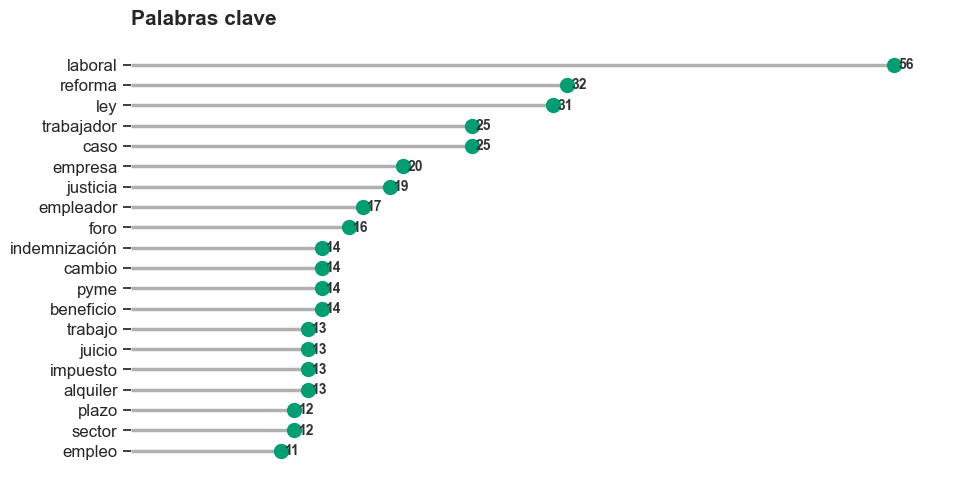

In [45]:
visualizar_palabras_clave_lollipop(palabras_clave)

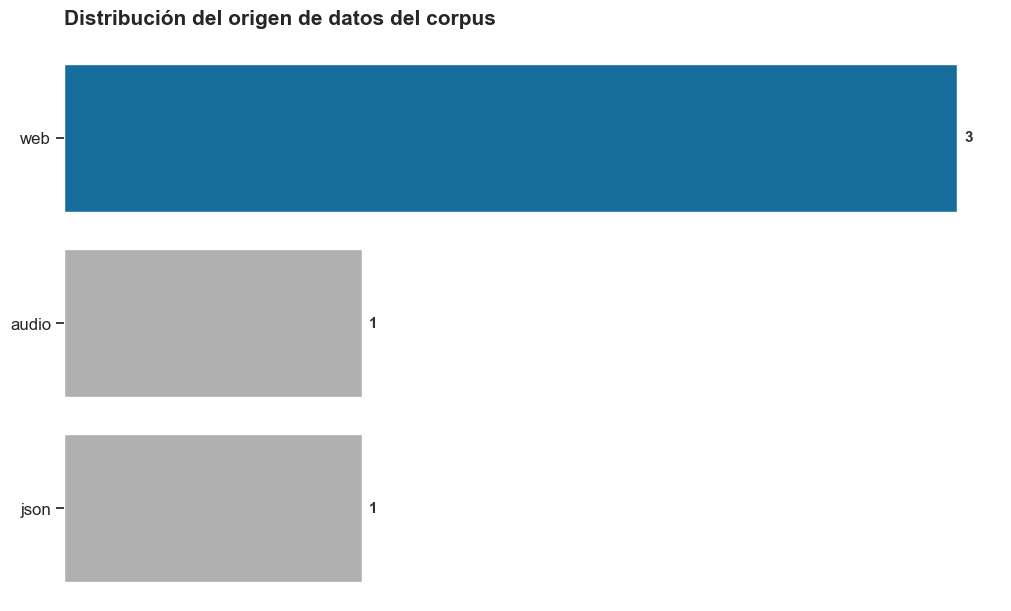

In [46]:
visualizar_origen(df_corpus)

## Parte 4: Pipeline Integrado (Orquestación)

**Objetivo:** Orquestar los componentes desarrollados en un flujo lógico unificado y persistir los hallazgos en formato estructurado. Todo sistema analítico debe poder guardar su estado final de forma estática.

In [ ]:
class PipelineMediatico:
    """
    Pipeline optimizado para la adquisición, unificación y análisis de corpus multimodales.
    
    Mejoras implementadas:
    - Manejo robusto de errores en cada etapa
    - Registro detallado de progreso
    - Separación clara de responsabilidades (SRP)
    - Opciones de configuración flexibles
    - Validación de entradas en cada paso
    - Reutilización de etapas individuales
    - Mejor manejo de recursos y memoria
    """
    
    def __init__(self, urls_web=None, url_audio=None, ruta_json=None, 
                 modelo_spacy="es_core_news_lg", directorio_salida="resultados"):
        """
        Inicializa el pipeline con los parámetros de configuración.
        
        Parámetros:
        -----------
        urls_web : list
            Lista de URLs para scraping web
        url_audio : str
            URL de YouTube para transcripción de audio
        ruta_json : str
            Ruta al archivo JSON de entrada
        modelo_spacy : str
            Nombre del modelo de spaCy a utilizar
        directorio_salida : str
            Directorio donde se guardarán los resultados
        """
        from pathlib import Path
        import os
        from datetime import datetime
        
        self.urls_web = urls_web or []
        self.url_audio = url_audio
        self.ruta_json = ruta_json
        self.modelo_spacy = modelo_spacy
        self.directorio_salida = Path(directorio_salida)
        
        # Estado interno del pipeline
        self.df = None
        self.analizador = None
        self.noticias = None
        self.audios = None
        self.jsons = None
        
        # Crear estructura de directorios de salida
        self._crear_estructura_directorios()
        
    def _crear_estructura_directorios(self):
        """Crea la estructura de directorios necesaria para los outputs."""
        (self.directorio_salida / "csv").mkdir(parents=True, exist_ok=True)
        (self.directorio_salida / "json").mkdir(parents=True, exist_ok=True)
        (self.directorio_salida / "logs").mkdir(parents=True, exist_ok=True)
        
    def _log_progreso(self, mensaje):
        """Registra un mensaje de progreso con timestamp."""
        from datetime import datetime
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        log_entry = f"[{timestamp}] {mensaje}"
        print(log_entry)
        
        # También guardar en archivo de log
        log_file = self.directorio_salida / "logs" / "pipeline.log"
        with open(log_file, "a", encoding="utf-8") as f:
            f.write(log_entry + "\n")
    
    def ejecutar_adquisicion_web(self):
        """Ejecuta únicamente la adquisición de datos web con manejo de errores."""
        self._log_progreso("Iniciando adquisición de datos web...")
        
        if not self.urls_web:
            self._log_progreso("Advertencia: No se proporcionaron URLs web")
            self.noticias = []
            return self.noticias
            
        try:
            self.noticias = extraer_noticias_web(self.urls_web)
            self._log_progreso(f"Adquisición web completada: {len(self.noticias)} noticias obtenidas")
            return self.noticias
        except Exception as e:
            self._log_progreso(f"Error en adquisición web: {str(e)}")
            self.noticias = []
            return []
    
    def ejecutar_adquisicion_audio(self):
        """Ejecuta únicamente la adquisición y transcripción de audio."""
        self._log_progreso("Iniciando adquisición y transcripción de audio...")
        
        if not self.url_audio:
            self._log_progreso("Advertencia: No se proporcionó URL de audio")
            self.audios = []
            return self.audios
            
        try:
            self.audios = transcribir_audios_youtube(self.url_audio) if self.url_audio else []
            self._log_progreso(f"Adquisición de audio completada: {len(self.audios)} transcripciones obtenidas")
            return self.audios
        except Exception as e:
            self._log_progreso(f"Error en adquisición de audio: {str(e)}")
            self.audios = []
            return []
    
    def ejecutar_carga_json(self):
        """Ejecuta únicamente la carga de datos JSON."""
        self._log_progreso("Iniciando carga de datos JSON...")
        
        if not self.ruta_json:
            self._log_progreso("Advertencia: No se proporcionó ruta JSON")
            self.jsons = []
            return self.jsons
            
        try:
            self.jsons = cargar_json_previo(self.ruta_json)
            self._log_progreso(f"Carga de JSON completada: {len(self.jsons)} registros obtenidos")
            return self.jsons
        except Exception as e:
            self._log_progreso(f"Error en carga de JSON: {str(e)}")
            self.jsons = []
            return []
    
    def ejecutar_unificacion(self):
        """Ejecuta únicamente la unificación de los datos adquiridos."""
        self._log_progreso("Iniciando unificación de datos...")
        
        # Asegurar que tenemos los datos (ejecutar adquisiciones si es necesario)
        if self.noticias is None:
            self.ejecutar_adquisicion_web()
        if self.audios is None:
            self.ejecutar_adquisicion_audio()
        if self.jsons is None:
            self.ejecutar_carga_json()
            
        try:
            self.df = unificar_corpus(self.noticias, self.audios, self.jsons)
            self._log_progreso(f"Unificación completada: {len(self.df)} documentos en el corpus")
            return self.df
        except Exception as e:
            self._log_progreso(f"Error en unificación: {str(e)}")
            # Devolver DataFrame vacío con columnas correctas en caso de error
            self.df = pd.DataFrame(columns=['titulo_o_fuente', 'texto', 'origen'])
            return self.df
    
    def ejecutar_analisis(self):
        """Ejecuta el análisis lingüístico del corpus unificado."""
        self._log_progreso("Iniciando análisis lingüístico...")
        
        # Asegurar que tenemos el corpus unificado
        if self.df is None:
            self.ejecutar_unificacion()
            
        if self.df is None or len(self.df) == 0:
            self._log_progreso("Advertencia: Corpus vacío, no se puede realizar análisis")
            self.analizador = None
            return None
            
        try:
            self.analizador = AnalizadorCorpus(df=self.df, modelo_spacy=self.modelo_spacy)
            self._log_progreso("Análisis lingüístico completado")
            return self.analizador
        except Exception as e:
            self._log_progreso(f"Error en análisis lingüístico: {str(e)}")
            self.analizador = None
            return None
    
    def ejecutar_pipeline(self, etapas=None):
        """
        Orquesta la ejecución completa del pipeline o etapas específicas.
        
        Parámetros:
        -----------
        etapas : list or None
            Lista de etapas a ejecutar. Si es None, ejecuta todas las etapas.
            Etapas disponibles: 'web', 'audio', 'json', 'unificar', 'analizar'
            
        Returns:
        --------
        AnalizadorCorpus or None
            Instancia del analizador con los resultados, o None si falló
        """
        self._log_progreso("=== INICIANDO EJECUCIÓN DEL PIPELINE ===")
        
        # Definir todas las etapas disponibles
        todas_etapas = ['web', 'audio', 'json', 'unificar', 'analizar']
        
        # Si no se especifican etapas, ejecutar todas
        if etapas is None:
            etapas = todas_etapas
            
        # Validar etapas
        etapas_invalidas = [etapa for etapa in etapas if etapa not in todas_etapas]
        if etapas_invalidas:
            raise ValueError(f"Etapas inválidas: {etapas_invalidas}. Etapas válidas: {todas_etapas}")
        
        try:
            # Ejecutar etapas en orden lógico
            if 'web' in etapas:
                self.ejecutar_adquisicion_web()
                
            if 'audio' in etapas:
                self.ejecutar_adquisicion_audio()
                
            if 'json' in etapas:
                self.ejecutar_carga_json()
                
            if 'unificar' in etapas:
                self.ejecutar_unificacion()
                
            if 'analizar' in etapas:
                self.ejecutar_analisis()
            
            self._log_progreso("=== EJECUCIÓN DEL PIPELINE COMPLETADA ===")
            return self.analizador
            
        except Exception as e:
            self._log_progreso(f"Error crítico en el pipeline: {str(e)}")
            return None
    
    def generar_reporte_y_exportar(self, 
                                 nombre_csv="corpus_resultante.csv", 
                                 nombre_json="estadisticas.json",
                                 ):
        """
        Exporta el dataframe y genera un reporte analítico completo.
        
        Parámetros:
        -----------
        nombre_csv : str
            Nombre del archivo CSV de salida
        nombre_json : str
            Nombre del archivo JSON de estadísticas
        
            
        Returns:
        --------
        dict
            Diccionario con las rutas de los archivos generados
        """
        self._log_progreso("Iniciando generación de reporte y exportación...")
        
        if self.df is None:
            self._log_progreso("Error: No hay datos para exportar. Ejecute el pipeline primero.")
            return {}
            
        if self.analizador is None:
            self._log_progreso("Advertencia: No hay analizador disponible. Se exportarán solo los datos básicos.")
        
        resultado = {}
        
        try:
            # 1. Exportar DataFrame a CSV (sin la columna 'doc' de spaCy)
            output_csv = self.directorio_salida / "csv" / nombre_csv
            df_exportar = self.df.copy()
            
            # Remover columnas no serializables
            if 'doc' in df_exportar.columns:
                df_exportar = df_exportar.drop(columns=['doc'])
                
            df_exportar.to_csv(output_csv, index=False, encoding='utf-8-sig')
            resultado['csv'] = str(output_csv)
            self._log_progreso(f"DataFrame exportado a: {output_csv}")
            
            # 2. Generar y exportar estadísticas y entidades a JSON
            output_json = self.directorio_salida / "json" / nombre_json
            
            if self.analizador is not None:
                estadisticas = self.analizador.estadisticas_corpus()
                entidades = self.analizador.extraer_entidades()
                
                # Información adicional sobre el pipeline
                metadata = {
                    "total_filas": len(self.df),
                    "columnas": list(self.df.columns),
                    "fuentes": self.df['origen'].value_counts().to_dict() if 'origen' in self.df.columns else {},
                    "modelo_spacy_utilizado": self.modelo_spacy,
                    "fecha_ejecucion": datetime.now().isoformat(),
                    "parametros_entrada": {
                        "urls_web": self.urls_web,
                        "url_audio": self.url_audio,
                        "ruta_json": self.ruta_json
                    }
                }
                
                reporte_final = {
                    "metadata": metadata,
                    "estadisticas": estadisticas,
                    "entidades_detectadas": entidades
                }
            else:
                # Reporte básico si no hay analizador
                reporte_final = {
                    "metadata": {
                        "total_filas": len(self.df),
                        "columnas": list(self.df.columns),
                        "fuentes": self.df['origen'].value_counts().to_dict() if 'origen' in self.df.columns else {},
                        "modelo_spacy_utilizado": self.modelo_spacy,
                        "fecha_ejecucion": datetime.now().isoformat(),
                        "analizador_disponible": False
                    },
                    "estadisticas": {},
                    "entidades_detectadas": {}
                }
            
            with open(output_json, "w", encoding="utf-8") as f:
                json.dump(reporte_final, f, ensure_ascii=False, indent=4)
                
            resultado['json'] = str(output_json)
            self._log_progreso(f"Estadísticas exportadas a: {output_json}")
            self._log_progreso("=== GENERACIÓN DE REPORTE COMPLETADA ===")
            return resultado
            
        except Exception as e:
            self._log_progreso(f"Error en generación de reporte: {str(e)}")
            return {}

In [54]:
pipeline_la_nacion = PipelineMediatico(urls_web=web_la_nacion, url_audio=yt_la_nacion)
pipeline_anfibia = PipelineMediatico(urls_web=web_anfibia)

In [55]:
pipeline_anfibia.ejecutar_pipeline()

[2026-04-26 14:47:41] === INICIANDO EJECUCIÓN DEL PIPELINE ===
[2026-04-26 14:47:41] Iniciando adquisición de datos web...
[2026-04-26 14:47:42] Adquisición web completada: 3 noticias obtenidas
[2026-04-26 14:47:42] Iniciando adquisición y transcripción de audio...
[2026-04-26 14:47:42] Advertencia: No se proporcionó URL de audio
[2026-04-26 14:47:42] Iniciando carga de datos JSON...
[2026-04-26 14:47:42] Advertencia: No se proporcionó ruta JSON
[2026-04-26 14:47:42] Iniciando unificación de datos...
✓ Corpus unificado exitosamente
  Total de documentos: 3
  Origen web: 3
  Origen audio: 0
  Origen json: 0
[2026-04-26 14:47:42] Unificación completada: 3 documentos en el corpus
[2026-04-26 14:47:42] Iniciando análisis lingüístico...
[2026-04-26 14:47:46] Análisis lingüístico completado
[2026-04-26 14:47:46] === EJECUCIÓN DEL PIPELINE COMPLETADA ===


In [56]:
pipeline_la_nacion.ejecutar_pipeline()


[2026-04-26 14:47:50] === INICIANDO EJECUCIÓN DEL PIPELINE ===
[2026-04-26 14:47:50] Iniciando adquisición de datos web...
[2026-04-26 14:47:53] Adquisición web completada: 3 noticias obtenidas
[2026-04-26 14:47:53] Iniciando adquisición y transcripción de audio...
Usando directorio: audios
Procesando video: https://www.youtube.com/watch?v=-EPmqM-DSX8
Descargando audio: Reforma laboral: empezó la cuenta regresiva. Editorial de Cristina Pérez (10/02/2026) (368s)
Transcribiendo audio: Reforma_laboral_-_empezo_la_cuenta_regresiva._Editorial_de_Cristina_Perez_10_02_2026.mp3 (8834733 bytes)


100%|██████████| 36804/36804 [02:09<00:00, 285.24frames/s]


✓ Transcripción completada: 5912 caracteres
Datos guardados en datos_json\-EPmqM-DSX8.json
[2026-04-26 14:50:10] Adquisición de audio completada: 1 transcripciones obtenidas
[2026-04-26 14:50:10] Iniciando carga de datos JSON...
[2026-04-26 14:50:10] Advertencia: No se proporcionó ruta JSON
[2026-04-26 14:50:10] Iniciando unificación de datos...
✓ Corpus unificado exitosamente
  Total de documentos: 4
  Origen web: 3
  Origen audio: 1
  Origen json: 0
[2026-04-26 14:50:10] Unificación completada: 4 documentos en el corpus
[2026-04-26 14:50:10] Iniciando análisis lingüístico...
[2026-04-26 14:50:12] Análisis lingüístico completado
[2026-04-26 14:50:12] === EJECUCIÓN DEL PIPELINE COMPLETADA ===


In [57]:
resultado_la_nacion = pipeline_la_nacion.generar_reporte_y_exportar(
    nombre_csv="corpus_la_nacion.csv",
    nombre_json="estadisticas_la_nacion.json"
)

resultado_pagina12 = pipeline_anfibia.generar_reporte_y_exportar(
    nombre_csv="corpus_anfibia.csv",
    nombre_json="estadisticas_anfibia.json"
)

[2026-04-26 14:51:50] Iniciando generación de reporte y exportación...
[2026-04-26 14:51:50] DataFrame exportado a: resultados\csv\corpus_la_nacion.csv
[2026-04-26 14:51:50] Estadísticas exportadas a: resultados\json\estadisticas_la_nacion.json
[2026-04-26 14:51:50] === GENERACIÓN DE REPORTE COMPLETADA ===
[2026-04-26 14:51:50] Iniciando generación de reporte y exportación...
[2026-04-26 14:51:50] DataFrame exportado a: resultados\csv\corpus_anfibia.csv
[2026-04-26 14:51:50] Estadísticas exportadas a: resultados\json\estadisticas_anfibia.json
[2026-04-26 14:51:50] === GENERACIÓN DE REPORTE COMPLETADA ===


> **Pausa de auditoría:**
> Imaginá que un equipo de periodismo de datos de tu facultad te pide el corpus procesado. ¿Qué información necesitaban ellos en el CSV plano versus qué preferiste consolidar en el JSON jerárquico? Pensá por qué separamos esas dos naturalezas de exportación y registralo.

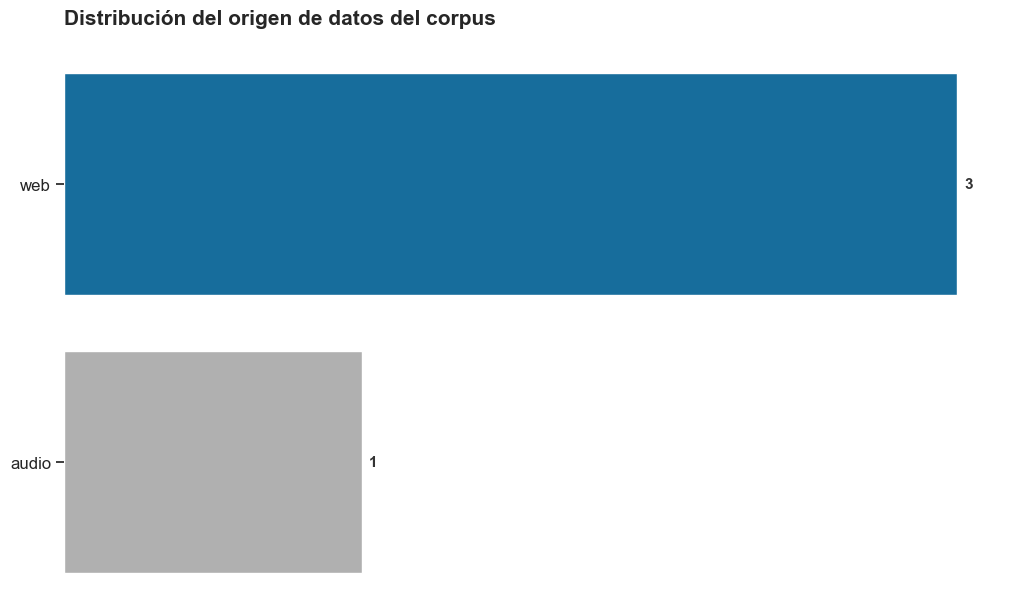

In [59]:
visualizar_origen(pipeline_la_nacion.df)

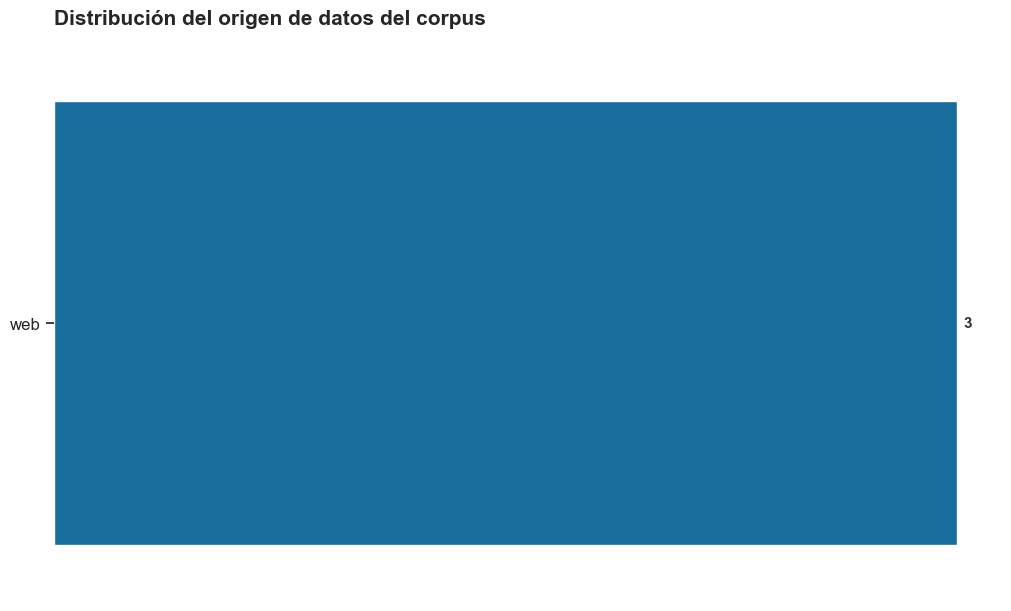

In [60]:
visualizar_origen(pipeline_anfibia.df)

C:\Users\iblis\AppData\Local\Temp\ipykernel_18964\3418478227.py:109: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


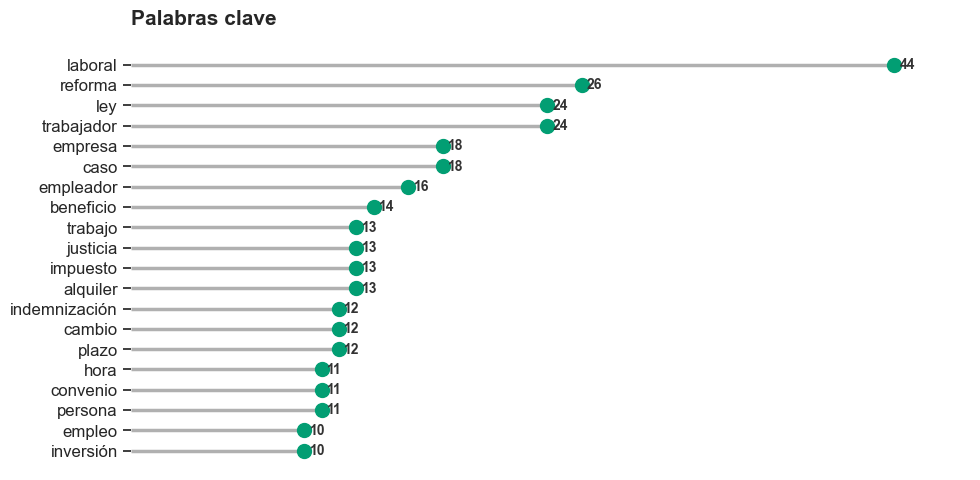

In [61]:
visualizar_palabras_clave_lollipop(pipeline_la_nacion.analizador.extraer_palabras_clave())

C:\Users\iblis\AppData\Local\Temp\ipykernel_18964\3418478227.py:109: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


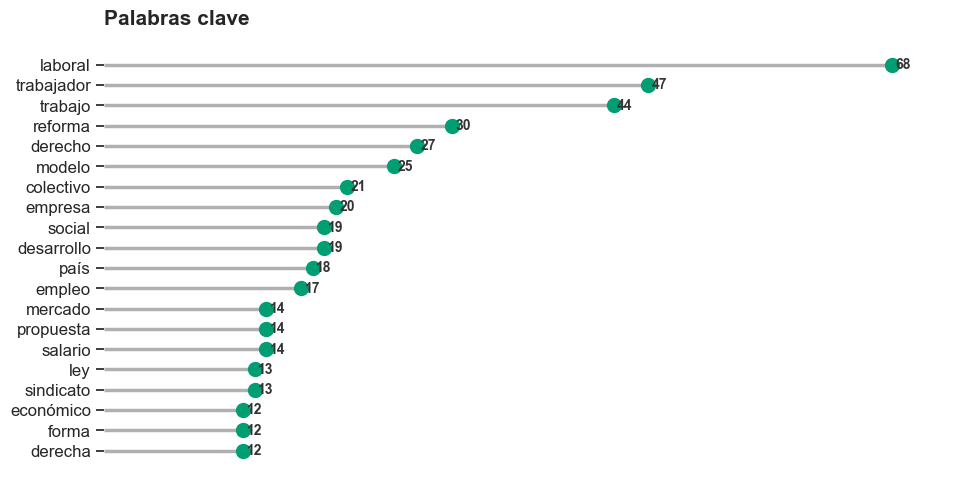

In [62]:
visualizar_palabras_clave_lollipop(pipeline_anfibia.analizador.extraer_palabras_clave())

In [63]:
visualizar_entidades_plotly(pipeline_la_nacion.analizador.extraer_entidades())

In [64]:
visualizar_entidades_plotly(pipeline_anfibia.analizador.extraer_entidades())

En un próximo procesamiento es necesario limpiar y filtrar entidades

## Parte 5: Dashboard Interactivo con Gradio

**Objetivo:** Diseñar una interfaz interactiva que reaccione dinámicamente frente al usuario, conectando el backend analítico con componentes preconstruidos de frontend.

> [!IMPORTANT]
> **Dilema de diseño**
> ¿Qué componentes elegirías para cada salida? Pedile a la IA tres layouts de estructura (por ejemplo: Pestañas vs. Columna vertical vs. Acordeón) para tu dashboard. Elegí el que consideres mejor para la experiencia de lectura evaluativa y descartá explícitamente los otros dos argumentando tu postura técnica.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

In [65]:
pipeline_la_nacion.df

,titulo_o_fuente,texto,origen
0,Se promulgó la reforma laboral: cuál es el imp...,Se promulgó la reforma laboral: cuál es el imp...,web
1,Qué es la reforma laboral de Milei que aprobó ...,Qué es la reforma laboral de Milei que aprobó ...,web
2,Oficial: estos son los impuestos que quedan ex...,"Hace poco más de un mes, la Ley de Modernizaci...",web
3,Reforma laboral: empezó la cuenta regresiva. E...,"de la intensidad fuera de lo común, mucha info...",audio


In [78]:

def actualizar_dashboard(nombre_medio):
    """
    Toma la decisión de qué instancia de Pipeline utilizar y 
    mapea los datos a las funciones de visualización originales.
    """
    
    pipeline = pipeline_la_nacion if nombre_medio == "La Nación" else pipeline_anfibia
    
    # Obtener el DataFrame y el Analizador de la instancia
    df_actual = pipeline.df
    analizador_actual = pipeline.analizador
    
    # Generar Títulos (Salida 1)
    tabla_out = df_actual[['titulo_o_fuente']].head(15).reset_index(drop=True)
    
    # Gráfico de Origen (Salida 2)
    fig_origen = visualizar_origen(df_actual)
    
    # Gráfico Lollipop (Salida 3) - Usa tu función sin modificar
    # Extraemos palabras clave usando el analizador de la instancia
    palabras_clave = analizador_actual.extraer_palabras_clave()[:15]
    fig_lollipop = visualizar_palabras_clave_lollipop(palabras_clave)
    
    # Gráfico Plotly de Entidades (Salida 4) - Usa tu función sin modificar
    entidades_dict = analizador_actual.extraer_entidades()
    fig_entidades = visualizar_entidades_plotly(entidades_dict)
    
    return tabla_out, fig_origen, fig_lollipop, fig_entidades

# ---  DISEÑO DE LA INTERFAZ (Propuesta 3, dashboad + sidebar) ---

with gr.Blocks(theme=gr.themes.Soft(), title="Comparativa medios") as demo:
    gr.Markdown("# Comparativa de La Nación y Anfibia sobre la reforma laboral")
    gr.Markdown("Análisis comparativo de corpus mediante Pipelines optimizados.")
    
    with gr.Row():
        # --- SIDEBAR (1/4 del ancho) ---
        with gr.Column(scale=1, variant="panel"):
            gr.Markdown("### 🛠 Configuración del Corpus")
            selector_medio = gr.Radio(
                choices=["La Nación", "Anfibia"], 
                label="Medio seleccionado", 
                value="La Nación"
            )
            #gr.Markdown("---")
            #gr.Markdown("**Pipeline Info:**")
            #gr.Info("Cada selección carga una instancia diferente de `PipelineMediatico`, actualizando lemas, entidades y orígenes.")

        # --- PANEL PRINCIPAL ---
        with gr.Column(scale=3):
            # Fila Superior: Datos y Origen
            with gr.Row():
                with gr.Column():
                    gr.Markdown("### 📄 Vista previa de Títulos")
                    out_tabla = gr.Dataframe(interactive=False, wrap=True)
                with gr.Column():
                    gr.Markdown("### 📊 Origen de Datos")
                    out_origen = gr.Plot()
            
            # Fila Inferior: Análisis Lingüístico
            with gr.Row():
                with gr.Column():
                    gr.Markdown("### 🍭 Pesos del Lenguaje (Lollipop)")
                    out_lollipop = gr.Plot()
                with gr.Column():
                    gr.Markdown("### 🤖 Mapa de Entidades")
                    out_entidades = gr.Plot()

    # ---CONEXIÓN DE EVENTOS ---
    selector_medio.change(
        fn=actualizar_dashboard,
        inputs=selector_medio,
        outputs=[out_tabla, out_origen, out_lollipop, out_entidades]
    )
    
    # Carga inicial al abrir la página
    demo.load(fn=actualizar_dashboard, inputs=selector_medio, outputs=[out_tabla, out_origen, out_lollipop, out_entidades])

# Lanzar el Dashboard
demo.launch()

C:\Users\iblis\AppData\Local\Temp\ipykernel_18964\3585799228.py:32: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="Comparativa medios") as demo:


* Running on local URL:  http://127.0.0.1:7867
* To create a public link, set `share=True` in `launch()`.


C:\Users\iblis\AppData\Local\Temp\ipykernel_18964\1778305567.py:109: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


---
## Cierre Formal y Checklist de Entrega

1. ¿Corriste el pipeline de principio a fin, comprobando que las funciones se anidan y comparten el DataFrame correctamente?
2. ¿Tu *AI Reflection Log* evidencia que cuestionaste a la IA y al modelo algorítmico, o todas tus celdas dicen "me devolvió un código y lo usé"?
3. ¿Revisaste el impacto visual de los gráficos garantizando que minimizan la "tinta algorítmica" (Data-Ink Ratio)?
4. ¿Justificaste tus decisiones de arquitectura técnica en el código de orquestación y exportación?

Si respondiste positivamente: felicitaciones, completaste el **TPI 1** demostrando un uso constructivo de la IA, asumiendo un rol profesional capaz de dirigir la automatización de forma estratégica e informada.